# Credit Card Fraud Prediction 

Tommy Tang <br>
Oct 1st, 2026

### Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import data_profiling
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

### Exploratory Data Analysis

In [2]:
#Load dataframe
df = pd.read_csv("credit_card_fraud_2026.csv")
df.set_index('transaction_id', inplace=True)
#Check completeness
df.info()
print(f'Shape of the dataset is {df.shape[0]} rows, {df.shape[1]} features')


<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 1 to 20000
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   amount_usd                    20000 non-null  float64
 1   merchant_category             20000 non-null  object 
 2   card_type                     20000 non-null  object 
 3   auth_method                   20000 non-null  object 
 4   channel                       20000 non-null  object 
 5   device_type                   20000 non-null  object 
 6   is_foreign_transaction        20000 non-null  bool   
 7   hours_since_last_txn          20000 non-null  float64
 8   txn_count_last_24h            20000 non-null  int64  
 9   distance_from_home_km         20000 non-null  float64
 10  card_age_months               20000 non-null  int64  
 11  customer_age                  20000 non-null  int64  
 12  account_balance_usd           20000 non-null  float64
 13  is_new

In [3]:
#Check feature datatypes
numerical = df.select_dtypes(['int', 'float64']).columns
print(f'Numerical features: {numerical}')
categorical = df.select_dtypes(['string', 'object']).columns
print(f'Categorical features: {categorical}')
boolean = df.select_dtypes(['bool']).columns
print(f'Boolean features: {boolean}')

Numerical features: Index(['amount_usd', 'hours_since_last_txn', 'txn_count_last_24h',
       'distance_from_home_km', 'card_age_months', 'customer_age',
       'account_balance_usd', 'cvv_retry_count', 'velocity_score',
       'time_of_day_hour', 'day_of_week', 'merchant_risk_score',
       'prior_disputes', 'is_fraud'],
      dtype='object')
Categorical features: Index(['merchant_category', 'card_type', 'auth_method', 'channel',
       'device_type'],
      dtype='object')
Boolean features: Index(['is_foreign_transaction', 'is_new_merchant', 'used_vpn',
       'ip_country_mismatch', 'billing_shipping_mismatch',
       'is_ai_generated_scam_attempt'],
      dtype='object')


In [4]:
#Convert boolean to int, one-hot-encode categorical features
df_ohe = pd.get_dummies(df, dtype=int)
df_ohe[boolean] = df_ohe[boolean].astype(int)
df_ohe.info()


<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 1 to 20000
Data columns (total 55 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   amount_usd                         20000 non-null  float64
 1   is_foreign_transaction             20000 non-null  int64  
 2   hours_since_last_txn               20000 non-null  float64
 3   txn_count_last_24h                 20000 non-null  int64  
 4   distance_from_home_km              20000 non-null  float64
 5   card_age_months                    20000 non-null  int64  
 6   customer_age                       20000 non-null  int64  
 7   account_balance_usd                20000 non-null  float64
 8   is_new_merchant                    20000 non-null  int64  
 9   used_vpn                           20000 non-null  int64  
 10  ip_country_mismatch                20000 non-null  int64  
 11  billing_shipping_mismatch          20000 non-null  int64  


In [5]:
#Check inconsistencies
#Check redundancies/duplicates
report = data_profiling.ProfileReport(df_ohe)
report
print('Dataset not appear to have any redundant features or inconsistent feature values')

Dataset not appear to have any redundant features or inconsistent feature values


Max correlation with label is cvv_retry_count=0.16
Min correlation with label is time_of_day_hour=-0.03
No features are highly correlated with target.


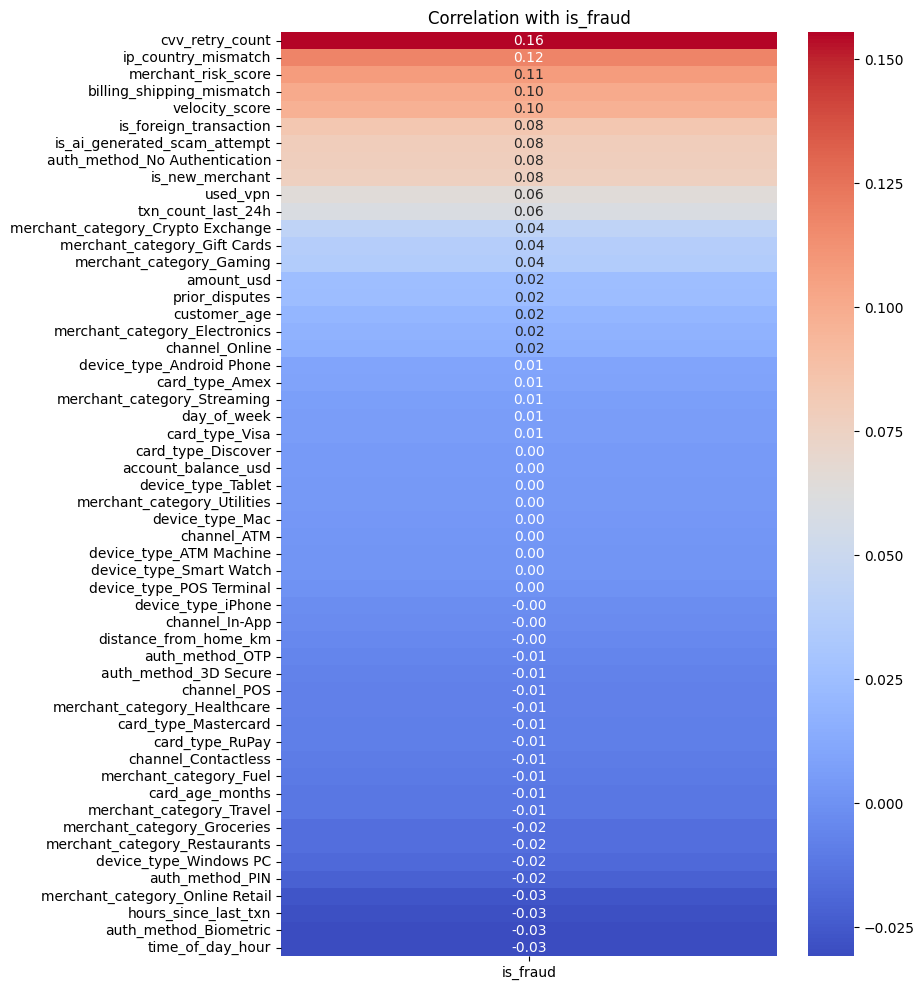

In [6]:
correlations = df_ohe.corr()[['is_fraud']]
correlations = correlations.drop(index='is_fraud')
%matplotlib inline
plt.figure(figsize=(8, 12))
plt.title("Correlation with is_fraud")
sns.heatmap(correlations.sort_values(by='is_fraud', ascending=False), cmap='coolwarm', fmt='.2f', annot=True)
print(f"Max correlation with label is {correlations.idxmax().iloc[0]}={correlations.max().iloc[0]:.2f}")
print(f"Min correlation with label is {correlations.idxmin().iloc[0]}={correlations.min().iloc[0]:.2f}")
print('No features are highly correlated with target.')

### Preprocessing

In [7]:
#Need to handle class imbalance -> SMOTENC (handle ohe variables)
#Need to split into training and test sets  
#Need to convert categorical to numerical -> One hot encoding
#Need to scale data for logistic regression -> Standard Scaler
#Need to perform 5-fold Cross-Validation 
#Within each fold: 1) SMOTENC 2) Standard Scaler
#Need to test multiple models
#Need to evaluate on different metrics F1, precision, recall (CM), ROC-AUC

#Split data into features and label
X = df.drop(columns='is_fraud')
y = df['is_fraud']

#Split data into train and test sets
from sklearn.model_selection import train_test_split
rs = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [8]:
#Convert features categories to list and get categorical, numeric, and boolean features
boolean = X.select_dtypes('bool').columns
X[boolean] = X[boolean].astype(int)
numerical = X.select_dtypes(['int', 'float']).columns.to_list()
categorical = X.select_dtypes('object', 'string').columns.to_list()

In [9]:
#Define column transformations required for SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
pre_smote = ColumnTransformer([("num", "passthrough", numerical), ("cat", OrdinalEncoder(unknown_value=-1, handle_unknown='use_encoded_value'), categorical), ("bool", "passthrough", boolean)])

In [10]:
#Inspect the data before and after pre_smote
X_train_before = X_train.copy()
X_train_pre = pre_smote.fit_transform(X_train)
X_train_after = pd.DataFrame(
    X_train_pre,
    columns=pre_smote.get_feature_names_out(),
    index=X_train.index,
)

print("Before:", X_train_before.shape)
display(X_train_before.head())

print("After pre_smote:", X_train_after.shape)
display(X_train_after.head())

print('Numerical features moved to starting index positions, followed by categorical features')

Before: (16000, 24)


,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,...,used_vpn,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes
transaction_id,,,,,,,,,,,,,,,,,,,,,
2652,24.13,Restaurants,Visa,PIN,POS,Smart Watch,False,5.52,4,11.36,...,False,False,False,0,21.3,19,0,False,33.9,1
1678,133.92,Healthcare,Mastercard,PIN,Online,Android Phone,False,15.05,4,34.56,...,False,False,False,0,26.7,4,5,False,36.0,2
17354,102.45,Groceries,Visa,3D Secure,POS,iPhone,False,6.90,4,2.82,...,False,False,False,0,16.5,21,6,False,21.4,0
3949,11.77,Gaming,Visa,3D Secure,Contactless,Windows PC,False,12.18,7,2.31,...,False,False,False,0,26.7,5,3,False,84.1,0
13605,27.79,Online Retail,Mastercard,3D Secure,Online,Windows PC,False,1.73,2,67.37,...,False,False,False,0,24.1,15,4,False,74.2,0


After pre_smote: (16000, 30)


,num__amount_usd,num__is_foreign_transaction,num__hours_since_last_txn,num__txn_count_last_24h,num__distance_from_home_km,num__card_age_months,num__customer_age,num__account_balance_usd,num__is_new_merchant,num__used_vpn,...,cat__card_type,cat__auth_method,cat__channel,cat__device_type,bool__is_foreign_transaction,bool__is_new_merchant,bool__used_vpn,bool__ip_country_mismatch,bool__billing_shipping_mismatch,bool__is_ai_generated_scam_attempt
transaction_id,,,,,,,,,,,,,,,,,,,,,
2652,24.13,False,5.52,4,11.36,52,22,9478.04,False,False,...,4.0,4.0,4.0,4.0,False,False,False,False,False,False
1678,133.92,False,15.05,4,34.56,33,23,11984.18,False,False,...,2.0,4.0,3.0,1.0,False,False,False,False,False,False
17354,102.45,False,6.9,4,2.82,39,49,4136.03,False,False,...,4.0,0.0,4.0,7.0,False,False,False,False,False,False
3949,11.77,False,12.18,7,2.31,48,61,897.6,True,False,...,4.0,0.0,1.0,6.0,False,True,False,False,False,False
13605,27.79,False,1.73,2,67.37,43,72,4800.0,True,False,...,2.0,0.0,3.0,6.0,False,True,False,False,False,False


Numerical features moved to starting index positions, followed by categorical features


In [11]:
#Apply SMOTENC
from imblearn.over_sampling import SMOTENC
numerical_indices = list(range(len(numerical)))
categorical_indices = list(range(len(numerical), len(numerical)+len(categorical)))
smote = SMOTENC(categorical_features=categorical_indices)

In [12]:
#Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
post_smote = ColumnTransformer([("num", StandardScaler(), numerical_indices), ("cat", OneHotEncoder(), categorical_indices)]) 

### Training

In [13]:
#Models 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

models = {   
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=rs),
    "SVM": SVC(probability=True, random_state=rs),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(n_jobs=-1, n_estimators=300, random_state=rs),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=rs)
}

In [14]:
#Cross-Validation Training Loop
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline

cv = StratifiedKFold(shuffle=True, random_state=rs)

scoring = ["f1", "precision", "recall", "roc_auc"]

results = []
pipelines = {}

for name, model in tqdm(models.items()):
    pipeline = Pipeline([("pre_smote", pre_smote), 
                         ("smote", smote), 
                         ("post_smote", post_smote), 
                         ("model", model)])
    pipelines[name] = pipeline
    
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({"Model": name, 
                    "F1": scores['test_f1'].mean(), 
                    "Precision": scores['test_precision'].mean(),
                    "Recall": scores['test_recall'].mean(),
                    "ROC-AUC": scores['test_roc_auc'].mean()
    })


  0%|          | 0/5 [00:00<?, ?it/s]

/Users/tommy/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommy/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommy/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/tommy/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/tommy/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/tommy/.venv/lib/pyth

In [15]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False).set_index('Model')
best_pipeline = pipelines['SVM']
print(results_df)
print(f"The best model is SVM, with F1 = {results_df.iloc[0,0]:.2f}")

                            F1  Precision    Recall   ROC-AUC
Model                                                        
SVM                   0.254984   0.249459  0.269630  0.876138
Logistic Regression   0.209699   0.120845  0.793333  0.925610
KNN                   0.165151   0.097412  0.542626  0.800318
HistGradientBoosting  0.139414   0.392308  0.084916  0.915519
Random Forest         0.071679   0.334603  0.040606  0.917564
The best model is SVM, with F1 = 0.25


In [16]:
#Select best model
best_pipeline.fit(X_train, y_train)


,steps,"[('pre_smote', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
#Evaluate best model
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

print("\nFinal Test Results")
print("------------------")

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("F1:",
      f1_score(y_test, y_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Final Test Results
------------------
Precision: 0.2361111111111111
Recall: 0.25
F1: 0.24285714285714285
ROC-AUC: 0.882590434444378

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3932
           1       0.24      0.25      0.24        68

    accuracy                           0.97      4000
   macro avg       0.61      0.62      0.61      4000
weighted avg       0.97      0.97      0.97      4000


Confusion Matrix:
[[3877   55]
 [  51   17]]


### Conclusion 

* The dataset is highly imbalanced, so SMOTE was applied to provide more training examples of the 'is_fraud=True' class. F1-score was used instead of accuracy to evaluate models for the same reason.
* No features showed strong correlation with targets, but weak features may have linear or non-linear interaction effects that correlate better with the target.
* I used 5-fold stratified cross-validation to produce a more robust estimate (CV-error) of the model's generalization error.
* Amongst the models tested, SVM had the highest training F1 (F1-train=0.25) and the highest test F1 (F1-test=0.24). Logistic regression was second, followed by KNN. 
* Hyperparameter tuning was not done, given the magnitude of F1.